In [29]:
# import
import cv2
import matplotlib.pyplot as plt
import numpy as np

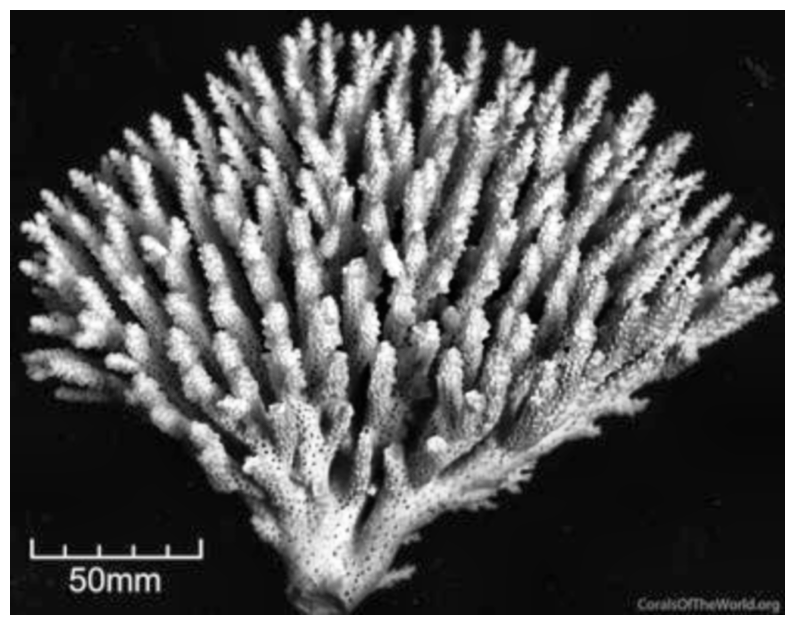

In [36]:
# edit image
image = cv2.imread("../data/raw/caespitose/tenuis1.jpg")
# resize 
height, width = image.shape[:2]
scale = 1024/width
image = cv2.resize(image, (1024, (int)(height * scale)))
# gray
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

gray = clahe.apply(gray)
# blur
blur = cv2.GaussianBlur(gray, (3,3), 0)
plt.figure(figsize=(10,10))
plt.imshow(blur, cmap="gray")
plt.axis("off")
plt.show()

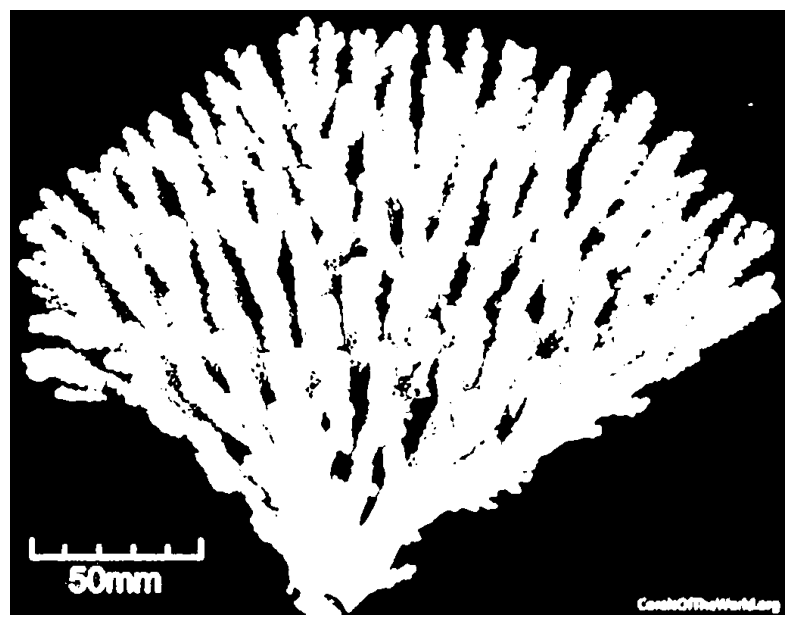

In [37]:
# threshold
(T, thresh) = cv2.threshold(blur, 40, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(10,10))
plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.show()

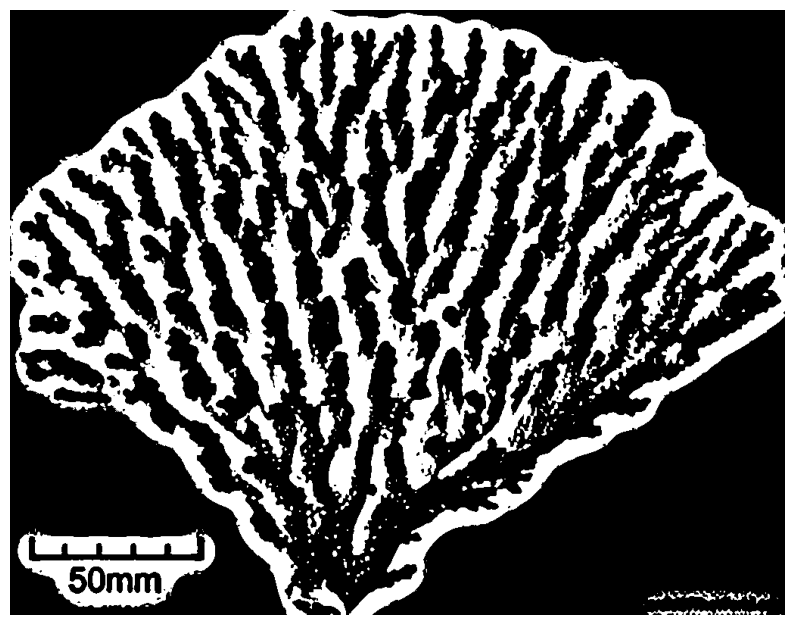

In [32]:
# adaptive threshold
a_thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 101, 10)
plt.figure(figsize=(10,10))
plt.imshow(a_thresh, cmap='gray')
plt.axis('off')
plt.show()

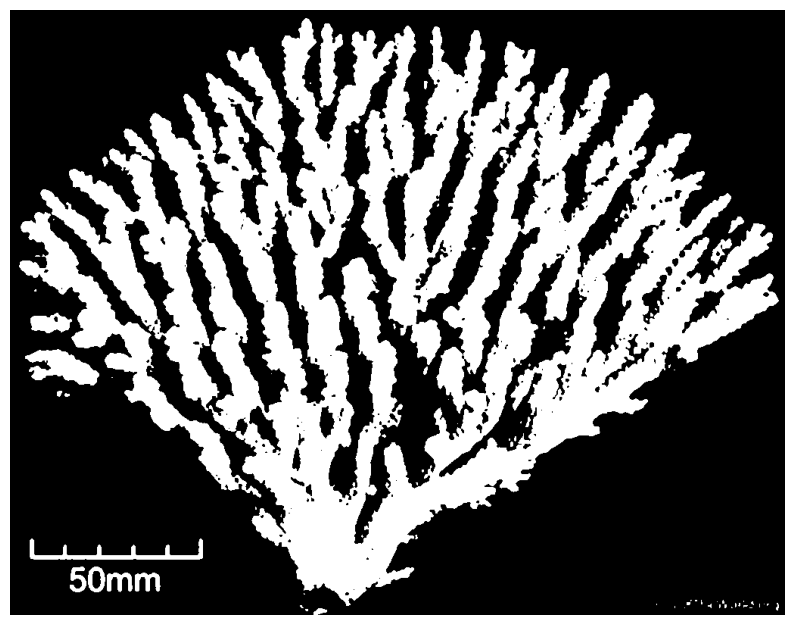

In [38]:
# otsu
_, otsu_mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(10,10))
plt.imshow(otsu_mask, cmap='gray')
plt.axis('off')
plt.show()

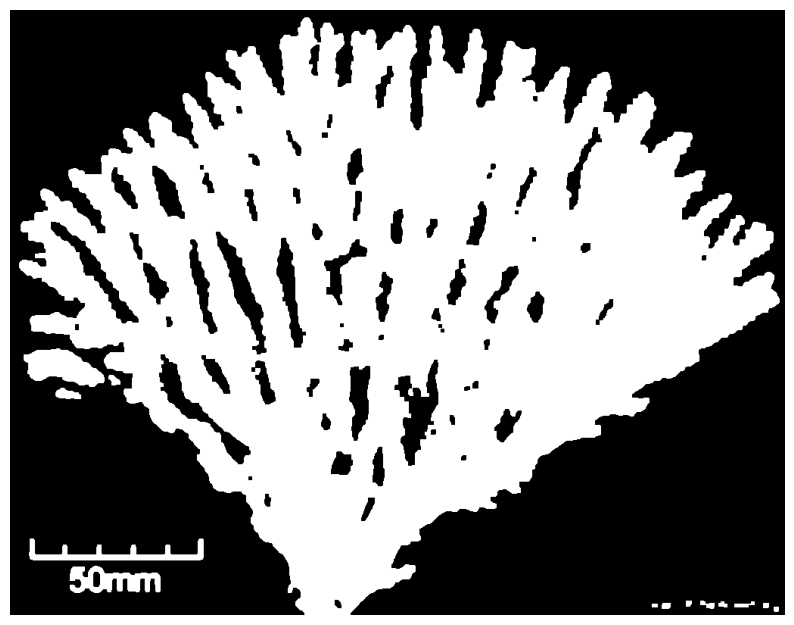

In [34]:
# cleaning
kernel = np.ones((5, 5), np.uint8)
open = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
close = cv2.morphologyEx(open, cv2.MORPH_CLOSE, kernel)
mask = close
plt.figure(figsize=(10,10))
plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

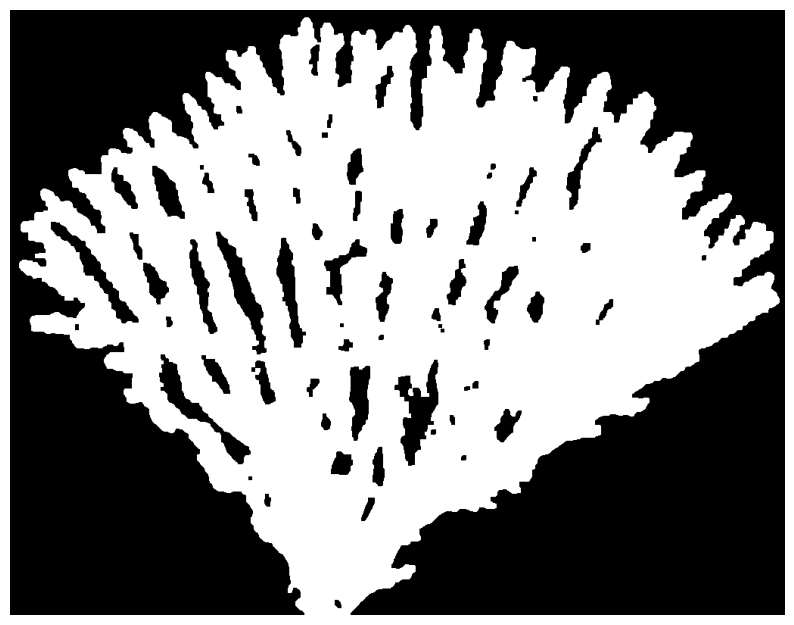

In [35]:
# remove the scale rulers by contouring
contours, hierarchy = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # find white shape boundaries
# only keep largest shape aka coral branch
if contours:
    largest_c = max(contours, key=cv2.contourArea)
    # draw largest
    stencil = np.zeros_like(mask)
    cv2.drawContours(stencil, [largest_c], 0, 255, -1)
    largest_mask = cv2.bitwise_and(mask, stencil)

# show
plt.figure(figsize=(10,10))
plt.imshow(largest_mask, cmap='gray')
plt.axis('off')
plt.show()


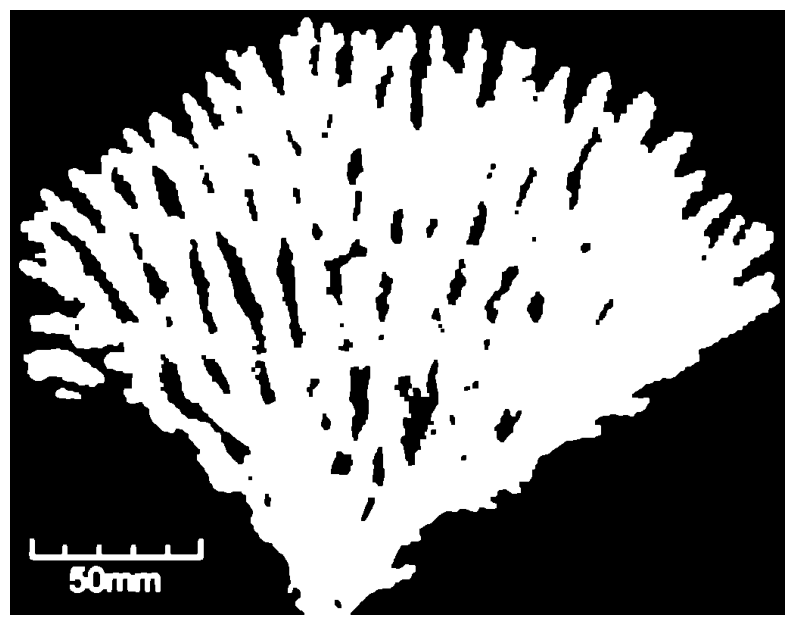

In [39]:
# connect branches that separated
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

clean = np.zeros_like(otsu_mask)

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area > 200:
        clean[labels == i] = 255
plt.figure(figsize=(10,10))
plt.imshow(clean, cmap='gray')
plt.axis('off')
plt.show()
